<a href="https://colab.research.google.com/github/Nutchayapon/Super_AI_Engineer-SS.6/blob/main/5D_Hackathon_Heart_Disease_Prediction_601661.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Super AI Engineer SS6] :  5 Domains Hackathon

#  Heart Disease Prediction

# Setup

In [ ]:
import os, csv, re, time, requests
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import userdata

# Data

In [ ]:
KAGGLE_API_KEY = userdata.get('KAGGLE_API')
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_API_KEY
!kaggle competitions download -c super-ai-engineer-ss-6-heart-disease-prediction
!unzip -q super-ai-engineer-ss-6-heart-disease-prediction

100% 4.30M/4.30M [00:00<00:00, 138MB/s]



In [ ]:
import os
os.listdir() # ดูว่ามีไฟล์ชื่ออะไรบ้าง

['.config',
 'train.csv',
 'sample_submission.csv',
 'test.csv',
 'super-ai-engineer-ss-6-heart-disease-prediction.zip',
 'sample_data']

## Train

In [ ]:
df_train = pd.read_csv('train.csv')
df_train.head(5)

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223084 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      223084 non-null  object 
 1   History of HeartDisease or Attack       221390 non-null  object 
 2   High Blood Pressure                     223084 non-null  object 
 3   Told High Cholesterol                   190898 non-null  object 
 4   Cholesterol Checked                     223084 non-null  object 
 5   Body Mass Index                         211302 non-null  float64
 6   Smoked 100+ Cigarettes                  223083 non-null  object 
 7   Diagnosed Stroke                        223084 non-null  object 
 8   Diagnosed Diabetes                      223081 non-null  object 
 9   Leisure Physical Activity               223084 non-null  object 
 10  Heavy Alcohol Consumption               2230

## Test

In [ ]:
df_test = pd.read_csv('test.csv')
df_test.head(5)

,ID,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,test_000001,Yes,Yes,Yes,24.84,No,No,No,Yes,No,Yes,No,Good,No,Female,Some college or technical school,"$20,000 to less than $25,000",71,Yes
1,test_000002,Yes,No,Yes,29.08,Yes,No,No,No,No,Yes,No,Fair,No,Female,College graduate,"$50,000 to less than $75,000",61,No
2,test_000003,Yes,Yes,Yes,35.23,Yes,No,No,No,No,Yes,No,Fair,Yes,Female,Some college or technical school,"Less than $10,000",67,Yes
3,test_000004,No,No,Yes,24.78,Yes,No,No,No,No,Yes,No,Fair,No,Female,Some college or technical school,"$50,000 to less than $75,000",50,Yes
4,test_000005,No,No,Yes,27.57,Yes,No,No,No,No,Yes,No,Fair,No,Male,Some college or technical school,"$25,000 to less than $35,000",40,Yes


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74361 entries, 0 to 74360
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID                                      74361 non-null  object 
 1   High Blood Pressure                     74361 non-null  object 
 2   Told High Cholesterol                   74361 non-null  object 
 3   Cholesterol Checked                     74361 non-null  object 
 4   Body Mass Index                         74361 non-null  float64
 5   Smoked 100+ Cigarettes                  74361 non-null  object 
 6   Diagnosed Stroke                        74361 non-null  object 
 7   Diagnosed Diabetes                      74361 non-null  object 
 8   Leisure Physical Activity               74361 non-null  object 
 9   Heavy Alcohol Consumption               74361 non-null  object 
 10  Health Care Coverage                    74361 non-null  ob

### note
> y (Target): History of HeartDisease or Attack



# Data Preprocessing

### Missing values in train.csv

In [ ]:
df_train.isna().sum() #check

,0
ID,0
History of HeartDisease or Attack,1694
High Blood Pressure,0
Told High Cholesterol,32186
Cholesterol Checked,0
Body Mass Index,11782
Smoked 100+ Cigarettes,1
Diagnosed Stroke,0
Diagnosed Diabetes,3
Leisure Physical Activity,0


In [ ]:
#เนื่องจาก data ทั้งหมดมี 223084 เเถว เเละ ค่าว่่างใน History of HeartDisease or Attack	  มีเพียง 1694 เเถว ดังนั้นเราจึงพิจารณา drop rows ที่เป็น Missing ทิ้งได้ เนื่องจากสัดส่วนน้อย

df_train_cleaned = df_train.dropna(subset=['History of HeartDisease or Attack'])

In [ ]:
# เช็คจำนวนค่าว่างในแต่ละ Features
print(df_train_cleaned.isna().sum())

ID                                            0
History of HeartDisease or Attack             0
High Blood Pressure                           0
Told High Cholesterol                     32043
Cholesterol Checked                           0
Body Mass Index                           11725
Smoked 100+ Cigarettes                        1
Diagnosed Stroke                              0
Diagnosed Diabetes                            3
Leisure Physical Activity                     0
Heavy Alcohol Consumption                     0
Health Care Coverage                          0
Doctor Visit Cost Barrier                     1
General Health                                1
Difficulty Walking                            3
Sex                                           0
Education Level                               0
Income Level                                  0
Age                                           0
Vegetable or Fruit Intake (1+ per Day)        0
dtype: int64


In [ ]:
# ดูว่าแต่ละคอลัมน์เป็นตัวเลข (float/int) หรือตัวหนังสือ (object)
print(df_train_cleaned.dtypes)

ID                                         object
History of HeartDisease or Attack          object
High Blood Pressure                        object
Told High Cholesterol                      object
Cholesterol Checked                        object
Body Mass Index                           float64
Smoked 100+ Cigarettes                     object
Diagnosed Stroke                           object
Diagnosed Diabetes                         object
Leisure Physical Activity                  object
Heavy Alcohol Consumption                  object
Health Care Coverage                       object
Doctor Visit Cost Barrier                  object
General Health                             object
Difficulty Walking                         object
Sex                                        object
Education Level                            object
Income Level                               object
Age                                         int64
Vegetable or Fruit Intake (1+ per Day)     object


#### Numerical Features
- Body Mass Index (BMI)

In [ ]:
bmi_mean = df_train_cleaned ['Body Mass Index'].mean()
df_train_cleaned['Body Mass Index'] =df_train_cleaned ['Body Mass Index'].fillna(bmi_mean)

/tmp/ipykernel_5534/3389156060.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['Body Mass Index'] =df_train_cleaned ['Body Mass Index'].fillna(bmi_mean)


In [ ]:
bmi_mean

np.float64(28.181722891278945)

#### Categorical Features
- Told High Cholesterol >> mode

- Smoked 100+ Cigarettes & Diagnosed Diabetes & Doctor Visit Cost Barrier  & General Health  & Difficulty Walking  >> drop

In [ ]:
# เปลี่ยน NaN เป็นคำว่า 'Unknown'
df_train_cleaned['Told High Cholesterol'] = df_train_cleaned['Told High Cholesterol'].fillna('Unknown')

/tmp/ipykernel_5534/1512753070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_cleaned['Told High Cholesterol'] = df_train_cleaned['Told High Cholesterol'].fillna('Unknown')


In [ ]:
df_train_cleaned['Told High Cholesterol'].value_counts()

,count
Told High Cholesterol,
No,109887
Yes,79460
Unknown,32043


In [ ]:
cols_to_drop_na = [
    'Smoked 100+ Cigarettes',
    'Diagnosed Diabetes',
    'Doctor Visit Cost Barrier',
    'General Health',
    'Difficulty Walking'
]

# ตัดแถวที่มีค่าว่างในคอลัมน์เหล่านี้ทิ้ง
df_train_cleaned = df_train_cleaned.dropna(subset=cols_to_drop_na)

In [ ]:
# re-check
print(df_train_cleaned.isna().sum())

ID                                        0
History of HeartDisease or Attack         0
High Blood Pressure                       0
Told High Cholesterol                     0
Cholesterol Checked                       0
Body Mass Index                           0
Smoked 100+ Cigarettes                    0
Diagnosed Stroke                          0
Diagnosed Diabetes                        0
Leisure Physical Activity                 0
Heavy Alcohol Consumption                 0
Health Care Coverage                      0
Doctor Visit Cost Barrier                 0
General Health                            0
Difficulty Walking                        0
Sex                                       0
Education Level                           0
Income Level                              0
Age                                       0
Vegetable or Fruit Intake (1+ per Day)    0
dtype: int64


# Encoding

#### Feature and Target

In [ ]:
# X และ y
y_train = df_train_cleaned['History of HeartDisease or Attack']
X_train = df_train_cleaned.drop('History of HeartDisease or Attack', axis=1)

# แปลง Target (y) ให้เป็นตัวเลข
if y_train.dtype == 'object':
    y_train = y_train.map({'No': 0, 'Yes': 1})

# ตรวจสอบผลลัพธ์
print("Target:")
print(y_train.value_counts())

Target:
History of HeartDisease or Attack
0    203316
1     18066
Name: count, dtype: int64


#### Feature Encoding ด้วย One-Hot Encoder

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. ลบคอลัมน์ ID ทิ้งก่อน เพราะไม่เกี่ยว
X_train_model = X_train.drop('ID', axis=1, errors='ignore')

# 2. ให้ Pandas ช่วยแยกประเภทคอลัมน์อัตโนมัติ
categorical_cols = X_train_model.select_dtypes(include=['object']).columns
numerical_cols = X_train_model.select_dtypes(include=['int64', 'float64']).columns

print(f"พบ Categorical Features: {len(categorical_cols)} คอลัมน์ ได้แก่\n{list(categorical_cols)}")
print(f"\nพบ Numerical Features: {len(numerical_cols)} คอลัมน์")

# 3. สร้าง Preprocessor (เพื่อนำไปยัดใส่ Pipeline ต่อไป)
preprocessor = ColumnTransformer(
    transformers=[
        # แปลงหมวดหมู่เป็น 0, 1 (handle_unknown='ignore' ช่วยป้องกัน Error เวลาเจอข้อมูลแปลกๆ ใน test.csv)
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),

        # ตัวเลขเดิม ปล่อยผ่าน (หรือจะใส่ StandardScaler ตรงนี้เลยก็ได้ถ้าต้องการ)
        ('num', 'passthrough', numerical_cols)
    ],
    remainder='passthrough'
)


X_train_encoded = preprocessor.fit_transform(X_train_model)
print(f"\nShape ของ X_train ก่อน Encoding: {X_train_model.shape}")
print(f"Shape ของ X_train หลัง Encoding: {X_train_encoded.shape}")

พบ Categorical Features: 16 คอลัมน์ ได้แก่
['High Blood Pressure', 'Told High Cholesterol', 'Cholesterol Checked', 'Smoked 100+ Cigarettes', 'Diagnosed Stroke', 'Diagnosed Diabetes', 'Leisure Physical Activity', 'Heavy Alcohol Consumption', 'Health Care Coverage', 'Doctor Visit Cost Barrier', 'General Health', 'Difficulty Walking', 'Sex', 'Education Level', 'Income Level', 'Vegetable or Fruit Intake (1+ per Day)']

พบ Numerical Features: 2 คอลัมน์

Shape ของ X_train ก่อน Encoding: (221382, 18)
Shape ของ X_train หลัง Encoding: (221382, 48)


In [ ]:
X_train_encoded

array([[ 0.  ,  1.  ,  0.  , ...,  1.  , 40.68, 64.  ],
       [ 1.  ,  0.  ,  1.  , ...,  0.  , 24.36, 50.  ],
       [ 0.  ,  1.  ,  0.  , ...,  1.  , 27.33, 61.  ],
       ...,
       [ 0.  ,  1.  ,  0.  , ...,  0.  , 18.94, 72.  ],
       [ 1.  ,  0.  ,  1.  , ...,  1.  , 29.29, 28.  ],
       [ 0.  ,  1.  ,  1.  , ...,  1.  , 23.67, 53.  ]])

# Feature Importance

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from lightgbm import LGBMClassifier
# from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.over_sampling import SMOTE

# # 1. สร้าง Pipeline เฉพาะกิจเพื่อหา Feature Importance
# # (เราใช้ preprocessor จากขั้นตอนที่แล้วที่คุณเพิ่งรันมาประกอบร่างได้เลย)
# pipeline_importance = ImbPipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('smote', SMOTE(random_state=42)),
#     ('classifier', LGBMClassifier(n_estimators=500, random_state=42, n_jobs=-1))
# ])

# print("กำลังเทรนโมเดลเพื่อหา Feature Importance (อาจใช้เวลาสักครู่)...")
# # 2. ทำการเทรนโมเดลด้วย X_train_model และ y_train
# pipeline_importance.fit(X_train_model, y_train)

# # 3. ดึงชื่อฟีเจอร์ออกมาให้ถูกต้อง (เพราะ One-Hot ทำให้คอลัมน์เพิ่มขึ้น)
# # เข้าไปดึงชื่อจาก OneHotEncoder ในขั้นตอน preprocessor
# ohe_feature_names = pipeline_importance.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_cols)
# # นำชื่อจาก One-Hot มาต่อกับชื่อคอลัมน์ตัวเลข (Numerical)
# all_feature_names = list(ohe_feature_names) + list(numerical_cols)

# # 4. ดึงคะแนนความสำคัญจาก LightGBM
# importances = pipeline_importance.named_steps['classifier'].feature_importances_

# # 5. สร้างเป็น DataFrame เพื่อให้ดูง่ายและนำไป Plot
# feat_imp_df = pd.DataFrame({
#     'Feature': all_feature_names,
#     'Importance': importances
# }).sort_values(by='Importance', ascending=False)

# # 6. แสดงผล Top 15 บนกราฟ
# plt.figure(figsize=(10, 8))
# plt.barh(feat_imp_df['Feature'][:15], feat_imp_df['Importance'][:15], color='royalblue')
# plt.gca().invert_yaxis() # กลับแกน Y ให้ตัวที่สำคัญที่สุดอยู่บนสุด
# plt.title('Top 15 Most Important Features for Heart Disease (LightGBM)')
# plt.xlabel('Importance Score (Number of Splits)')
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

# # พิมพ์ตาราง Top 7 ดูชัดๆ
# print("\n🔥 Top 7 ปัจจัยที่สำคัญที่สุด:")
# print(feat_imp_df.head(7))

กำลังเทรน Random Forest เพื่อหา Feature Importance...


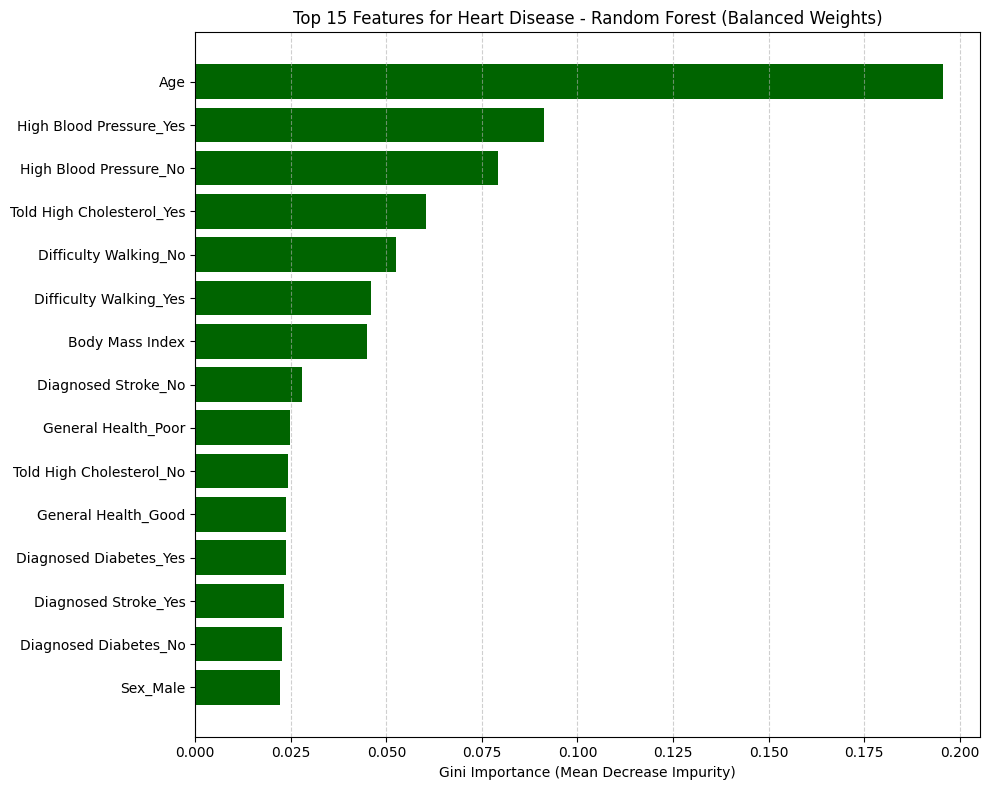


✅ Top 10 ฟีเจอร์ที่สำคัญที่สุดจาก Random Forest:
                      Feature  Importance
47                        Age    0.195538
1     High Blood Pressure_Yes    0.091168
0      High Blood Pressure_No    0.079111
4   Told High Cholesterol_Yes    0.060295
26      Difficulty Walking_No    0.052474
27     Difficulty Walking_Yes    0.045980
46            Body Mass Index    0.044998
9         Diagnosed Stroke_No    0.027917
24        General Health_Poor    0.024794
2    Told High Cholesterol_No    0.024347


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# 1. สร้าง Pipeline (เอา SMOTE ออก และใส่ Random Forest แทน)
# หมายเหตุ: 'preprocessor' คือตัวแปรที่คุณนิยามไว้ก่อนหน้า (ColumnTransformer)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,           # จำนวนต้นไม้ (ยิ่งเยอะยิ่งเสถียร)
        class_weight='balanced',    # แก้ Imbalance โดยเพิ่ม Weight ให้ Class น้อย
        random_state=42,
        n_jobs=-1,                  # ใช้ CPU ทุก Core ช่วยประมวลผล
        max_depth=15,               # ป้องกันการจำข้อมูลเกินไป (Overfitting)
        min_samples_leaf=5          # ช่วยให้ค่า Importance ไม่กระโดดตาม Noise
    ))
])

print("กำลังเทรน Random Forest เพื่อหา Feature Importance...")
# 2. เทรนโมเดล (X_train_model และ y_train คือข้อมูลดิบก่อนเข้า preprocessor)
rf_pipeline.fit(X_train_model, y_train)

# 3. ดึงชื่อฟีเจอร์ (รองรับทั้ง One-Hot และ Numerical)
ohe_feature_names = rf_pipeline.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_cols)
all_feature_names = list(ohe_feature_names) + list(numerical_cols)

# 4. ดึง Feature Importance
importances = rf_pipeline.named_steps['classifier'].feature_importances_

# 5. สร้าง DataFrame สรุปผล
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 6. พล็อตกราฟ Top 15
plt.figure(figsize=(10, 8))
plt.barh(feat_imp_df['Feature'][:15], feat_imp_df['Importance'][:15], color='darkgreen')
plt.gca().invert_yaxis()
plt.title('Top 15 Features for Heart Disease - Random Forest (Balanced Weights)')
plt.xlabel('Gini Importance (Mean Decrease Impurity)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n✅ Top 10 ฟีเจอร์ที่สำคัญที่สุดจาก Random Forest:")
print(feat_imp_df.head(10))

# Pipeline (SMOTE + CV)

In [ ]:
!pip install optuna

In [ ]:
import optuna
import xgboost as xgb
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import fbeta_score, make_scorer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 🏎️ STEP 1: ใช้ X_train_encoded
# สุ่มมา 20% เพื่อความรวดเร็ว (ถ้า Array ใหญ่มากต้องใช้การ Index แบบ Numpy)
indices = np.random.choice(X_train_encoded.shape[0], int(X_train_encoded.shape[0] * 0.20), replace=False)
X_sub = X_train_encoded[indices]
y_sub = y_train.iloc[indices]

f2_scorer = make_scorer(fbeta_score, beta=2)

def objective_encoded_data(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 2.5),

        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1
    }

    # 🌟 STEP 2: Pipeline เหลือแค่ SMOTE + XGB
    # ไม่ต้องมี preprocessor แล้ว เพราะข้อมูลเป็นตัวเลขหมดแล้ว
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42, sampling_strategy=0.7)),
        ('xgb', xgb.XGBClassifier(**params))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # ส่ง X_sub (ที่เป็น encoded แล้ว) เข้าไปเลย
    scores = cross_val_score(pipeline, X_sub, y_sub, cv=cv, scoring=f2_scorer, n_jobs=-1)
    return np.mean(scores)

print(f"🚀 เริ่มจูนบนข้อมูลที่ Encoded แล้ว ({X_sub.shape[0]} แถว)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective_encoded_data, n_trials=30)

print("\n✨ เรียบร้อย! Best Params สำหรับข้อมูล Encoded ของคุณ:")
print(study.best_params)

[I 2026-04-03 16:26:46,470] A new study created in memory with name: no-name-56ad9b99-cb4d-4d46-ae17-206ce0ccac69


🚀 เริ่มจูนบนข้อมูลที่ Encoded แล้ว (44276 แถว)...


[I 2026-04-03 16:27:30,224] Trial 0 finished with value: 0.23293497359186005 and parameters: {'n_estimators': 306, 'max_depth': 7, 'learning_rate': 0.09471600610473022, 'subsample': 0.6657091572630254, 'colsample_bytree': 0.6275335207259454, 'scale_pos_weight': 1.444058615281831}. Best is trial 0 with value: 0.23293497359186005.
[I 2026-04-03 16:27:51,448] Trial 1 finished with value: 0.23877486429854544 and parameters: {'n_estimators': 148, 'max_depth': 7, 'learning_rate': 0.04786165841993464, 'subsample': 0.6049147451284156, 'colsample_bytree': 0.7438625411445141, 'scale_pos_weight': 1.1545131813861829}. Best is trial 1 with value: 0.23877486429854544.
[I 2026-04-03 16:28:00,670] Trial 2 finished with value: 0.5229331747986201 and parameters: {'n_estimators': 129, 'max_depth': 3, 'learning_rate': 0.029592477234347603, 'subsample': 0.7389783397641561, 'colsample_bytree': 0.8503064990597042, 'scale_pos_weight': 2.2501403483847495}. Best is trial 2 with value: 0.5229331747986201.
[I 202


✨ เรียบร้อย! Best Params สำหรับข้อมูล Encoded ของคุณ:
{'n_estimators': 226, 'max_depth': 3, 'learning_rate': 0.02228298887857809, 'subsample': 0.7932180600152233, 'colsample_bytree': 0.8235059197996532, 'scale_pos_weight': 2.4806903630495882}


# Apply with test

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. นำ Best Params ที่คุณหาได้มากำหนดลงใน Dictionary
best_xgb_params = {'n_estimators': 226, 'max_depth': 3, 'learning_rate': 0.02228298887857809, 'subsample': 0.7932180600152233, 'colsample_bytree': 0.8235059197996532, 'scale_pos_weight': 2.4806903630495882}

# 2. ประกอบร่าง Final Pipeline
final_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb.XGBClassifier(**best_xgb_params))
])

# 3. เทรนโมเดล (ใช้ X_train_model และ y_train ตัวเต็ม 100%)
print("🏋️‍♂️ กำลังเทรน Final XGBoost Model ด้วยข้อมูลทั้งหมด 100%...")
final_pipeline.fit(X_train_model, y_train)
print("✅ เทรนโมเดลเสร็จสมบูรณ์!")

# 4. เตรียมข้อมูล Test และทำนายผล
print("🔮 กำลังทำนายผลข้อมูล test.csv...")
X_test_model = df_test.drop('ID', axis=1, errors='ignore')
test_predictions = final_pipeline.predict(X_test_model)

# 🌟 แปลงผลลัพธ์ 0 เป็น 'No' และ 1 เป็น 'Yes'
predicted_labels = np.where(test_predictions == 1, 'Yes', 'No')

# 5. ประกอบร่างและบันทึกไฟล์ส่ง Kaggle
submission_df = pd.DataFrame({
    'ID': df_test['ID'],
    'History of HeartDisease or Attack': predicted_labels
})

submission_filename = 'submission_final_xgboost_yes_no.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"🎉 สร้างไฟล์ {submission_filename} เรียบร้อย!")
# ลองเช็คผลลัพธ์ 5 แถวแรกดูเพื่อความชัวร์
print(submission_df.head())

🏋️‍♂️ กำลังเทรน Final XGBoost Model ด้วยข้อมูลทั้งหมด 100%...
✅ เทรนโมเดลเสร็จสมบูรณ์!
🔮 กำลังทำนายผลข้อมูล test.csv...
🎉 สร้างไฟล์ submission_final_xgboost_yes_no.csv เรียบร้อย!
            ID History of HeartDisease or Attack
0  test_000001                               Yes
1  test_000002                                No
2  test_000003                               Yes
3  test_000004                                No
4  test_000005                                No
